# Translation-Based ROI Augmentation



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
print('Drive mounted.')
print('Your Drive root:', os.listdir('/content/drive/MyDrive')[:8], '...')


Mounted at /content/drive
Drive mounted.
Your Drive root: ['Classroom', 'L1S1', 'Sem Regitration', 'Photo', 'CamScanner 09-22-2023 16.25.jpg', 'Combinational Circuits  and Sequential circuits..gsheet', 'Coprocessor vs Peripherals table.gsheet', 'Untitled document (4).gdoc'] ...


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 0b — Verify dependencies
# ══════════════════════════════════════════════════════════════════════════

import cv2, numpy as np, matplotlib
from pathlib import Path
from tqdm.notebook import tqdm
import random, os, json
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print(f'OpenCV   : {cv2.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print('All dependencies ready.')


OpenCV   : 4.13.0
NumPy    : 2.0.2
Matplotlib: 3.10.0
All dependencies ready.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm.notebook import tqdm
import random, os, json
from collections import defaultdict
print('Imports OK.')


Imports OK.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════

DRIVE_BASE = '/content/drive/MyDrive/FYP'

# ── Input folders ─────────────────
CROP_OCT_DIR  = f'{DRIVE_BASE}/data/images'
CROP_MASK_DIR = f'{DRIVE_BASE}/data/masks'

# ── Output folders  ───────────────────
OUT_OCT_DIR   = f'{DRIVE_BASE}/data/augmented_new/crop_oct'
OUT_MASK_DIR  = f'{DRIVE_BASE}/data/augmented_new/crop_mask'

# ── Translation augmentation parameters ──────────────────────────────────
N_TRANSLATIONS    = 5     # translated crops per image (total = N+1 with original)
MARGIN            = 20    # pixels of context added around lesion bbox
MAX_SHIFT_X       = 40    # max horizontal shift  [-MAX_SHIFT_X, +MAX_SHIFT_X]
MAX_SHIFT_Y       = 20    # max vertical shift    [-MAX_SHIFT_Y, +MAX_SHIFT_Y]
MIN_LESION_MARGIN = 5     # min pixels between lesion edge and crop edge after shift
SAVE_ORIGINAL     = True  # also save the unshifted baseline crop
BG_THRESHOLD      = 15    # mask pixels below this are background
SEED              = 42
EXTENSIONS        = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff'}

# ── Class colour map (must match your masks exactly) ─────────────────────
CLASS_INFO = {
    0: {'name': 'Background',    'color': (0,   0,   0)},
    1: {'name': 'Retinal Layer', 'color': (255, 0,   255)},
    2: {'name': 'PED',           'color': (255, 255, 0)},
    3: {'name': 'SRF',           'color': (255, 0,   0)},
    4: {'name': 'IRF',           'color': (0,   0,   255)},
    5: {'name': 'RPE',           'color': (0,   255, 0)},
}

# ── Resize parameters (NEW) ──────────────────────────────────────────────
TARGET_SIZE = 256

# ── Validate paths before continuing ─────────────────────────────────────
for label, path in [('crop_oct',  CROP_OCT_DIR),
                     ('crop_mask', CROP_MASK_DIR)]:
    if not Path(path).exists():
        raise FileNotFoundError(
            f'Input folder not found: {path}\n'
            f'Check DRIVE_BASE and folder names.'
        )

os.makedirs(OUT_OCT_DIR,  exist_ok=True)
os.makedirs(OUT_MASK_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)

print('Config loaded and paths verified.')
print(f'  Input  OCT    : {CROP_OCT_DIR}')
print(f'  Input  mask   : {CROP_MASK_DIR}')
print(f'  Output OCT    : {OUT_OCT_DIR}')
print(f'  Output mask   : {OUT_MASK_DIR}')
print(f'  TARGET_SIZE   : {TARGET_SIZE}×{TARGET_SIZE}  ← resize BEFORE augmentation')
print(f'  Translations  : {N_TRANSLATIONS} per image')
print(f'  Max shift X/Y : {MAX_SHIFT_X}px / {MAX_SHIFT_Y}px')
n_input = len([f for f in Path(CROP_OCT_DIR).iterdir()
               if f.suffix.lower() in EXTENSIONS])
print(f'  Input images  : {n_input}')
n_out_est = n_input * (N_TRANSLATIONS + (1 if SAVE_ORIGINAL else 0))
print(f'  Expected output: ~{n_out_est} crops  ({n_out_est/max(n_input,1):.0f}× multiplier)')


Config loaded and paths verified.
  Input  OCT    : /content/drive/MyDrive/FYP/data/images
  Input  mask   : /content/drive/MyDrive/FYP/data/masks
  Output OCT    : /content/drive/MyDrive/FYP/data/augmented_new/crop_oct
  Output mask   : /content/drive/MyDrive/FYP/data/augmented_new/crop_mask
  TARGET_SIZE   : 256×256  ← resize BEFORE augmentation
  Translations  : 5 per image
  Max shift X/Y : 40px / 20px
  Input images  : 3049
  Expected output: ~18294 crops  (6× multiplier)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CORE FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════

def resize_to_target(oct_bgr, mask_bgr, target_size=256):

    oct_resized  = cv2.resize(
        oct_bgr, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    mask_resized = cv2.resize(
        mask_bgr, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return oct_resized, mask_resized


def get_lesion_bbox(mask_bgr, bg_threshold=BG_THRESHOLD):
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    fg = (mask_rgb > bg_threshold).any(axis=2)     # H×W bool
    rows = np.where(np.any(fg, axis=1))[0]
    cols = np.where(np.any(fg, axis=0))[0]
    if len(rows) == 0:
        return None
    return int(rows[0]), int(rows[-1]), int(cols[0]), int(cols[-1])


def get_baseline_crop_window(lesion_bbox, img_h, img_w, margin=MARGIN):
    r_min, r_max, c_min, c_max = lesion_bbox
    r0 = max(0, r_min - margin)
    r1 = min(img_h - 1, r_max + margin)
    c0 = max(0, c_min - margin)
    c1 = min(img_w - 1, c_max + margin)
    return r0, r1, c0, c1


def translate_crop_window(base_window, shift_r, shift_c,
                          lesion_bbox, img_h, img_w,
                          min_lesion_margin=MIN_LESION_MARGIN):

    r0_base, r1_base, c0_base, c1_base = base_window
    crop_h = r1_base - r0_base
    crop_w = c1_base - c0_base
    l_r0, l_r1, l_c0, l_c1 = lesion_bbox

    # Proposed shifted position
    r0_new = r0_base + shift_r
    c0_new = c0_base + shift_c
    r1_new = r0_new + crop_h
    c1_new = c0_new + crop_w

    # ── Constraint 1: crop must stay within image ─────────────────────
    r0_new = max(0, r0_new)
    c0_new = max(0, c0_new)
    r1_new = min(img_h - 1, r1_new)
    c1_new = min(img_w - 1, c1_new)

    # Recompute r0/c0 if r1/c1 were clamped (preserve crop size)
    r0_new = max(0, r1_new - crop_h)
    c0_new = max(0, c1_new - crop_w)

    # ── Constraint 2: lesion must stay inside crop with margin ────────
    # Lesion position relative to new crop origin
    lesion_inside_r0 = l_r0 - r0_new
    lesion_inside_r1 = l_r1 - r0_new
    lesion_inside_c0 = l_c0 - c0_new
    lesion_inside_c1 = l_c1 - c0_new

    crop_h_actual = r1_new - r0_new
    crop_w_actual = c1_new - c0_new

    # Check all four sides have enough margin
    if (lesion_inside_r0 < min_lesion_margin or
        lesion_inside_c0 < min_lesion_margin or
        lesion_inside_r1 > crop_h_actual - min_lesion_margin or
        lesion_inside_c1 > crop_w_actual - min_lesion_margin):
        return None, None, False

    actual_dr = r0_new - r0_base
    actual_dc = c0_new - c0_base
    return (r0_new, r1_new, c0_new, c1_new), (actual_dr, actual_dc), True


def sample_valid_translations(base_window, lesion_bbox, img_h, img_w,
                              n_translations, max_shift_x, max_shift_y,
                              min_lesion_margin=MIN_LESION_MARGIN,
                              max_attempts=500):

    valid_windows = []
    seen_shifts   = set()

    for _ in range(max_attempts):
        if len(valid_windows) >= n_translations:
            break

        shift_r = random.randint(-max_shift_y, max_shift_y)
        shift_c = random.randint(-max_shift_x, max_shift_x)

        # Skip zero shift (that's the original crop)
        if shift_r == 0 and shift_c == 0:
            continue

        win, actual_shift, ok = translate_crop_window(
            base_window, shift_r, shift_c,
            lesion_bbox, img_h, img_w, min_lesion_margin
        )

        if not ok:
            continue

        # Deduplicate: skip if this exact window already collected
        key = win
        if key in seen_shifts:
            continue

        seen_shifts.add(key)
        valid_windows.append((win, actual_shift))

    return valid_windows


def crop_image_and_mask(oct_bgr, mask_bgr, window):
    """
    Crop both OCT and mask identically using the given window.
    window: (r0, r1, c0, c1)
    Returns (oct_crop, mask_crop) — same spatial size, no resize.
    """
    r0, r1, c0, c1 = window
    return oct_bgr[r0:r1+1, c0:c1+1], mask_bgr[r0:r1+1, c0:c1+1]


print('Core functions ready (including resize_to_target).')

Core functions ready (including resize_to_target).


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — Verify one sample before processing everything
# ══════════════════════════════════════════════════════════════════════════

oct_dir  = Path(CROP_OCT_DIR)
mask_dir = Path(CROP_MASK_DIR)

all_files = sorted([f for f in oct_dir.iterdir()
                    if f.suffix.lower() in EXTENSIONS])
print(f'Found {len(all_files)} OCT crops in input folder.')
if len(all_files) == 0:
    raise FileNotFoundError(f'No images found in {CROP_OCT_DIR}')

# ── Load sample ────────────────────────────────────────────────────────
sample_path = all_files[0]
oct_bgr_orig  = cv2.imread(str(sample_path))
mask_bgr_orig = cv2.imread(str(mask_dir / sample_path.name), cv2.IMREAD_COLOR)
orig_h, orig_w = oct_bgr_orig.shape[:2]

# ── Resize FULL image + mask to TARGET_SIZE × TARGET_SIZE ──
oct_bgr, mask_bgr = resize_to_target(oct_bgr_orig, mask_bgr_orig, TARGET_SIZE)
img_h, img_w = oct_bgr.shape[:2]   # now always TARGET_SIZE × TARGET_SIZE
print(f'Resize: {orig_w}×{orig_h}  →  {img_w}×{img_h}')

# ── Get lesion bbox + baseline window ─────────────────────────────────
lesion_bbox  = get_lesion_bbox(mask_bgr)
base_window  = get_baseline_crop_window(lesion_bbox, img_h, img_w)
translations = sample_valid_translations(
    base_window, lesion_bbox, img_h, img_w,
    N_TRANSLATIONS, MAX_SHIFT_X, MAX_SHIFT_Y
)

print(f'\nSample: {sample_path.name}')
print(f'  Original size    : {orig_w}w × {orig_h}h')
print(f'  Resized to       : {img_w}w × {img_h}h  ← augmentation happens here')
print(f'  Lesion bbox      : rows {lesion_bbox[0]}–{lesion_bbox[1]},  cols {lesion_bbox[2]}–{lesion_bbox[3]}')
print(f'  Baseline window  : rows {base_window[0]}–{base_window[1]},  cols {base_window[2]}–{base_window[3]}')
print(f'  Baseline crop    : {base_window[1]-base_window[0]+1}h × {base_window[3]-base_window[2]+1}w')
print(f'  Valid translations found: {len(translations)} / {N_TRANSLATIONS} requested')
for i, (win, shift) in enumerate(translations):
    print(f'    [{i+1}] shift=({shift[0]:+d}r, {shift[1]:+d}c)  →  '
          f'rows {win[0]}–{win[1]}, cols {win[2]}–{win[3]}')

Found 3049 OCT crops in input folder.
Resize: 570×380  →  256×256

Sample: 0.png
  Original size    : 570w × 380h
  Resized to       : 256w × 256h  ← augmentation happens here
  Lesion bbox      : rows 9–114,  cols 18–247
  Baseline window  : rows 0–134,  cols 0–255
  Baseline crop    : 135h × 256w
  Valid translations found: 5 / 5 requested
    [1] shift=(+0r, +0c)  →  rows 0–128, cols 0–255
    [2] shift=(+0r, +0c)  →  rows 0–127, cols 0–255
    [3] shift=(+2r, +0c)  →  rows 2–136, cols 0–255
    [4] shift=(+3r, +0c)  →  rows 3–137, cols 0–255
    [5] shift=(+0r, +0c)  →  rows 0–124, cols 0–255


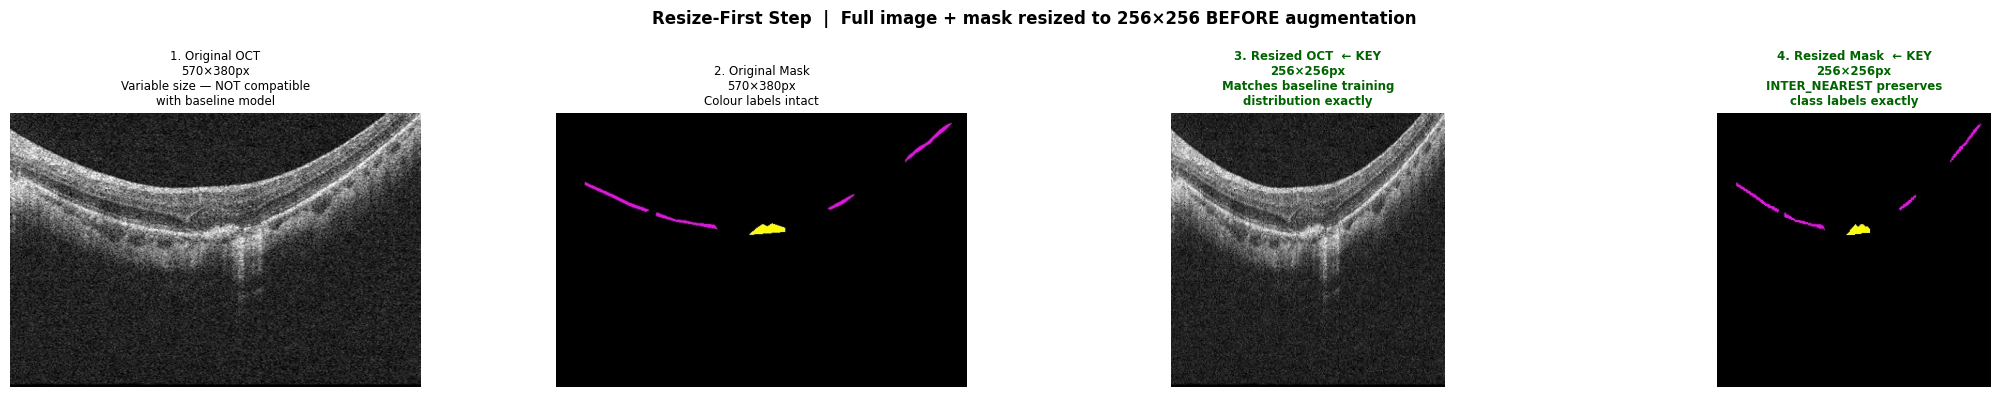

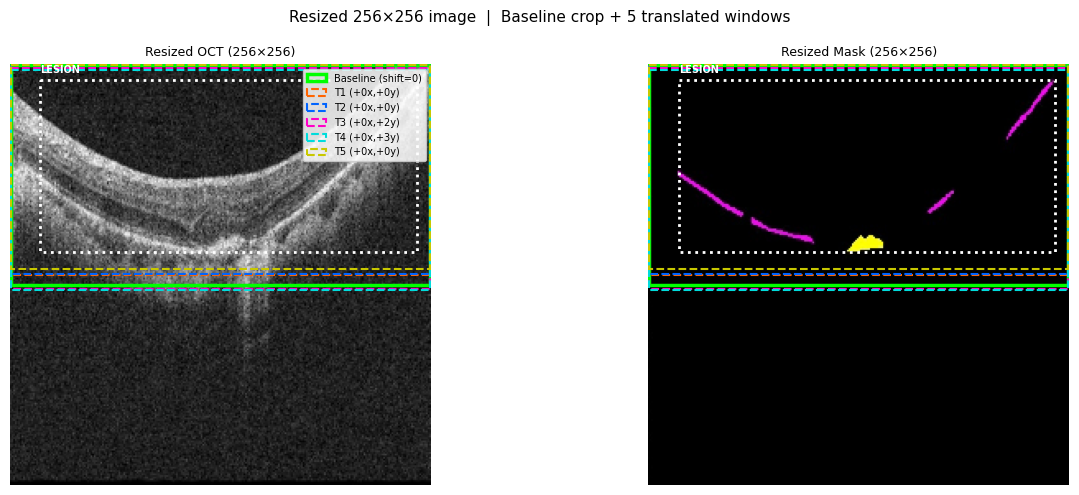

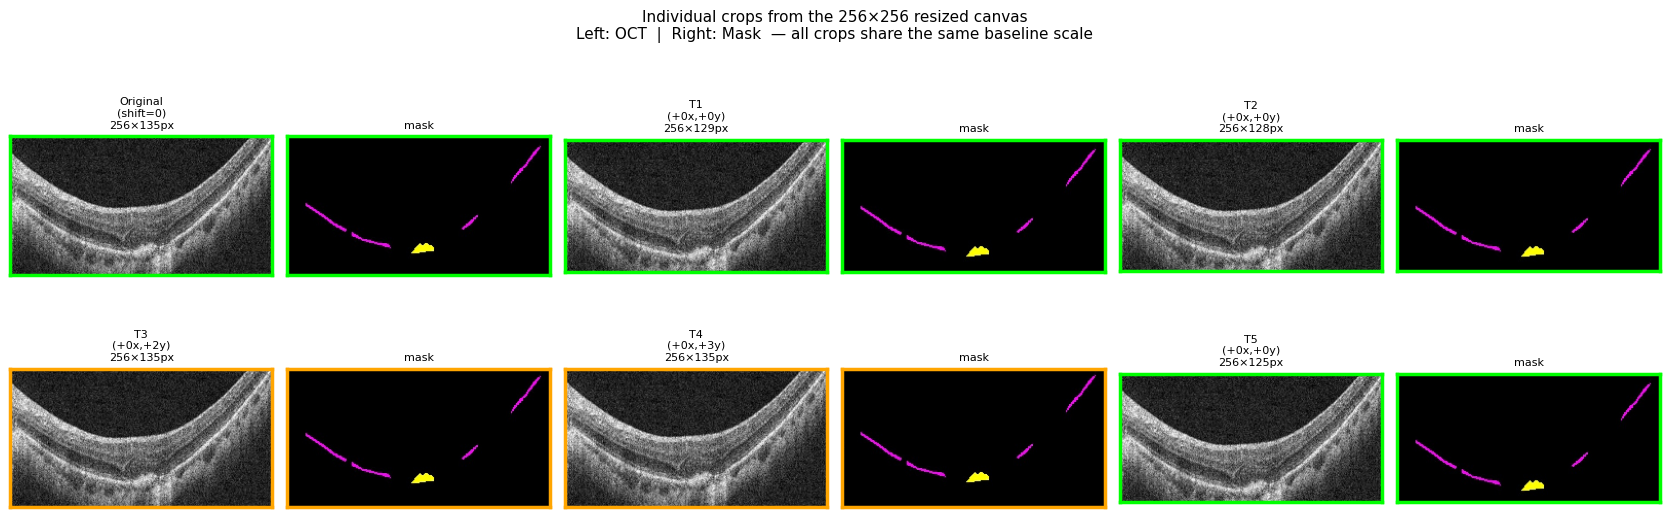

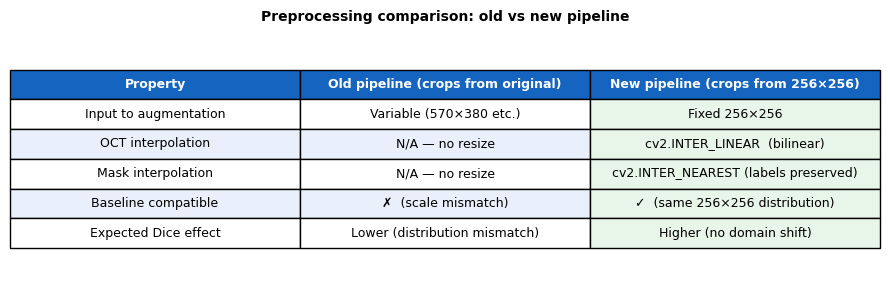

Visualisation complete.
All crop windows drawn from the 256×256 resized canvas.
If crops look correct, run the next cell to process all images.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — Visualise the resize-first pipeline + crop windows
# ══════════════════════════════════════════════════════════════════════════

import matplotlib.patches as patches

# ── Panel A: 4-column before/after comparison ─────────────────────────────
fig_a, axes_a = plt.subplots(1, 4, figsize=(22, 4))
fig_a.suptitle(
    f'Resize-First Step  |  Full image + mask resized to {TARGET_SIZE}×{TARGET_SIZE} '
    'BEFORE augmentation',
    fontsize=12, fontweight='bold'
)

panels = [
    (cv2.cvtColor(oct_bgr_orig,  cv2.COLOR_BGR2RGB),
     f'1. Original OCT\n{orig_w}×{orig_h}px\nVariable size — NOT compatible\nwith baseline model',
     'gray', None),
    (cv2.cvtColor(mask_bgr_orig, cv2.COLOR_BGR2RGB),
     f'2. Original Mask\n{orig_w}×{orig_h}px\nColour labels intact',
     None,   None),
    (cv2.cvtColor(oct_bgr,  cv2.COLOR_BGR2RGB),
     f'3. Resized OCT  ← KEY\n{TARGET_SIZE}×{TARGET_SIZE}px\nMatches baseline training\ndistribution exactly',
     'gray', 'green'),
    (cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB),
     f'4. Resized Mask  ← KEY\n{TARGET_SIZE}×{TARGET_SIZE}px\nINTER_NEAREST preserves\nclass labels exactly',
     None,   'green'),
]
for ax, (img, title, cmap, border) in zip(axes_a, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=8.5,
                 color='darkgreen' if border else 'black',
                 fontweight='bold' if border else 'normal')
    ax.axis('off')
    if border:
        for sp in ax.spines.values():
            sp.set_edgecolor(border); sp.set_linewidth(3); sp.set_visible(True)
plt.tight_layout()
plt.show()

# ── Panel B: resized image with all crop windows overlaid ─────────────────
N_SHOW = len(translations);  N_COLS = 3
window_colors = [(0,255,0),(255,100,0),(0,100,255),(255,0,200),(0,220,220),(200,200,0)]

oct_rgb  = cv2.cvtColor(oct_bgr,  cv2.COLOR_BGR2RGB)
mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)

fig_b, axes_b = plt.subplots(1, 2, figsize=(14, 5))
fig_b.suptitle(
    f'Resized {TARGET_SIZE}×{TARGET_SIZE} image  |  '
    f'Baseline crop + {len(translations)} translated windows', fontsize=11)

for ax, bg_img, title in zip(axes_b, [oct_rgb, mask_rgb],
                              [f'Resized OCT ({TARGET_SIZE}×{TARGET_SIZE})',
                               f'Resized Mask ({TARGET_SIZE}×{TARGET_SIZE})']):
    ax.imshow(bg_img, cmap='gray' if 'OCT' in title else None)
    l_r0,l_r1,l_c0,l_c1 = lesion_bbox
    ax.add_patch(patches.Rectangle((l_c0,l_r0),l_c1-l_c0,l_r1-l_r0,
                  lw=2,edgecolor='white',facecolor='none',linestyle=':'))
    ax.text(l_c0,l_r0-4,'LESION',color='white',fontsize=7,fontweight='bold')
    r0,r1,c0,c1 = base_window
    col = np.array(window_colors[0])/255
    ax.add_patch(patches.Rectangle((c0,r0),c1-c0,r1-r0,
                  lw=2.5,edgecolor=col,facecolor='none',label='Baseline (shift=0)'))
    for i,(win,shift) in enumerate(translations):
        wr0,wr1,wc0,wc1=win; col=np.array(window_colors[(i+1)%len(window_colors)])/255
        ax.add_patch(patches.Rectangle((wc0,wr0),wc1-wc0,wr1-wr0,
                      lw=1.5,edgecolor=col,facecolor='none',linestyle='--',
                      label=f'T{i+1} ({shift[1]:+d}x,{shift[0]:+d}y)'))
    ax.set_title(title,fontsize=9); ax.axis('off')
axes_b[0].legend(loc='upper right',fontsize=7,framealpha=0.85)
plt.tight_layout(); plt.show()

# ── Panel C: individual crop grid ─────────────────────────────────────────
all_windows = [(base_window,(0,0))] + translations
labels = ['Original\n(shift=0)'] + \
         [f'T{i+1}\n({s[1]:+d}x,{s[0]:+d}y)' for i,(_,s) in enumerate(translations)]
n_items=len(all_windows); n_rows=int(np.ceil(n_items/N_COLS))
fig_c,axes_c=plt.subplots(n_rows,N_COLS*2,figsize=(N_COLS*2*2.8,n_rows*3.0))
if axes_c.ndim==1: axes_c=axes_c.reshape(1,-1)
fig_c.suptitle(
    f'Individual crops from the {TARGET_SIZE}×{TARGET_SIZE} resized canvas\n'
    'Left: OCT  |  Right: Mask  — all crops share the same baseline scale',
    fontsize=11)
for idx,((win,shift),label) in enumerate(zip(all_windows,labels)):
    row=idx//N_COLS; col=(idx%N_COLS)*2
    oct_c,mask_c=crop_image_and_mask(oct_bgr,mask_bgr,win)
    h,w=oct_c.shape[:2]; border='lime' if shift==(0,0) else 'orange'
    axes_c[row,col  ].imshow(cv2.cvtColor(oct_c, cv2.COLOR_BGR2RGB),cmap='gray')
    axes_c[row,col+1].imshow(cv2.cvtColor(mask_c,cv2.COLOR_BGR2RGB))
    axes_c[row,col  ].set_title(f'{label}\n{w}×{h}px',fontsize=8)
    axes_c[row,col+1].set_title('mask',fontsize=8)
    for ax in [axes_c[row,col],axes_c[row,col+1]]:
        for sp in ax.spines.values(): sp.set_edgecolor(border);sp.set_linewidth(2.5);sp.set_visible(True)
        ax.set_xticks([]); ax.set_yticks([])
for idx in range(n_items,n_rows*N_COLS):
    row=idx//N_COLS;col=(idx%N_COLS)*2
    axes_c[row,col].axis('off');axes_c[row,col+1].axis('off')
plt.tight_layout(); plt.show()

# ── Panel D: preprocessing summary table ──────────────────────────────────
fig_d,ax_d=plt.subplots(figsize=(9,3))
ax_d.axis('off')
tbl_data=[
    ['Property',             'Old pipeline (crops from original)', f'New pipeline (crops from {TARGET_SIZE}×{TARGET_SIZE})'],
    ['Input to augmentation', f'Variable ({orig_w}×{orig_h} etc.)', f'Fixed {TARGET_SIZE}×{TARGET_SIZE}'],
    ['OCT interpolation',     'N/A — no resize',                   'cv2.INTER_LINEAR  (bilinear)'],
    ['Mask interpolation',    'N/A — no resize',                   'cv2.INTER_NEAREST (labels preserved)'],
    ['Baseline compatible',   '✗  (scale mismatch)',               '✓  (same 256×256 distribution)'],
    ['Expected Dice effect',  'Lower (distribution mismatch)',      'Higher (no domain shift)'],
]
tbl=ax_d.table(cellText=tbl_data[1:],colLabels=tbl_data[0],loc='center',cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0,1.7)
for (r,c),cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#1565C0'); cell.set_text_props(color='white',fontweight='bold')
    elif c==2 and r>0: cell.set_facecolor('#E8F5E9')
    elif r%2==0: cell.set_facecolor('#EAF0FB')
ax_d.set_title('Preprocessing comparison: old vs new pipeline',
               fontsize=10, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()

print('Visualisation complete.')
print(f'All crop windows drawn from the {TARGET_SIZE}×{TARGET_SIZE} resized canvas.')
print('If crops look correct, run the next cell to process all images.')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — Process ALL images and save augmented crops
# ══════════════════════════════════════════════════════════════════════════

stats = {
    'total_input'      : len(all_files),
    'saved_original'   : 0,
    'saved_translated' : 0,
    'skipped_empty'    : 0,
    'skipped_unreadable': 0,
    'partial'          : 0,
}
translations_per_image = []

for fpath in tqdm(all_files, desc='Augmenting'):

    # ── Load ────────────────────────────────────────────────────────────
    oct_bgr  = cv2.imread(str(fpath))
    mask_bgr = cv2.imread(str(mask_dir / fpath.name), cv2.IMREAD_COLOR)

    if oct_bgr is None or mask_bgr is None:
        stats['skipped_unreadable'] += 1
        continue

    # ── Resize FULL image + mask to TARGET_SIZE × TARGET_SIZE
    oct_bgr, mask_bgr = resize_to_target(oct_bgr, mask_bgr, TARGET_SIZE)
    img_h, img_w = oct_bgr.shape[:2]   # always TARGET_SIZE × TARGET_SIZE

    # ── Lesion bbox (on resized 256×256 image) ───────────────────────────
    lesion_bbox = get_lesion_bbox(mask_bgr)
    if lesion_bbox is None:
        stats['skipped_empty'] += 1
        continue

    # ── Baseline crop window ─────────────────────────────────────────────
    base_window = get_baseline_crop_window(lesion_bbox, img_h, img_w)

    # ── Save original crop ───────────────────────────────────────────────
    if SAVE_ORIGINAL:
        oct_crop, mask_crop = crop_image_and_mask(oct_bgr, mask_bgr, base_window)
        out_name = fpath.stem + '_t00.png'
        cv2.imwrite(str(Path(OUT_OCT_DIR)  / out_name), oct_crop)
        cv2.imwrite(str(Path(OUT_MASK_DIR) / out_name), mask_crop)
        stats['saved_original'] += 1

    # ── Sample valid translations ────────────────────────────────────────
    valid_translations = sample_valid_translations(
        base_window, lesion_bbox, img_h, img_w,
        N_TRANSLATIONS, MAX_SHIFT_X, MAX_SHIFT_Y
    )

    if len(valid_translations) < N_TRANSLATIONS:
        stats['partial'] += 1

    translations_per_image.append(len(valid_translations))

    # ── Save each translated crop ────────────────────────────────────────
    for t_idx, (win, shift) in enumerate(valid_translations, start=1):
        oct_crop, mask_crop = crop_image_and_mask(oct_bgr, mask_bgr, win)

        # Filename encodes shift for traceability
        out_name = f"{fpath.stem}_t{t_idx:02d}_r{shift[0]:+d}_c{shift[1]:+d}.png"
        cv2.imwrite(str(Path(OUT_OCT_DIR)  / out_name), oct_crop)
        cv2.imwrite(str(Path(OUT_MASK_DIR) / out_name), mask_crop)
        stats['saved_translated'] += 1

total_saved = stats['saved_original'] + stats['saved_translated']
print()
print('=' * 60)
print('  AUGMENTATION COMPLETE  (resize-first pipeline)')
print('=' * 60)
print(f'  Resize step       : {TARGET_SIZE}×{TARGET_SIZE} applied to every image')
print('=' * 60)
print(f'  Input images          : {stats["total_input"]}')
print(f'  Skipped (empty mask)  : {stats["skipped_empty"]}')
print(f'  Skipped (unreadable)  : {stats["skipped_unreadable"]}')
print(f'  Partial (<{N_TRANSLATIONS} shifts)    : {stats["partial"]}')
print(f'  Saved original crops  : {stats["saved_original"]}')
print(f'  Saved translated crops: {stats["saved_translated"]}')
print(f'  Total output pairs    : {total_saved}')
print(f'  Effective multiplier  : {total_saved / max(stats["total_input"],1):.1f}×')
print('=' * 60)

# Save augmentation metadata
meta = {
    'config': {
        'resize_first': True,
        'target_size': TARGET_SIZE,
        'n_translations': N_TRANSLATIONS,
        'margin': MARGIN,
        'max_shift_x': MAX_SHIFT_X,
        'max_shift_y': MAX_SHIFT_Y,
        'min_lesion_margin': MIN_LESION_MARGIN,
        'seed': SEED,
    },
    'stats': stats,
    'total_saved': total_saved,
}
with open(Path(OUT_OCT_DIR).parent / 'augmentation_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved → {Path(OUT_OCT_DIR).parent}/augmentation_meta.json')

# Colab: flush OS write buffer so files appear in Drive immediately
import subprocess
subprocess.run(['sync'], check=False)
print('\nDrive sync complete. Files are visible in Google Drive.')
print(f'Open Drive → {OUT_OCT_DIR.replace("/content/drive/MyDrive/", "")} to verify.')


Augmenting:   0%|          | 0/3049 [00:00<?, ?it/s]


  AUGMENTATION COMPLETE  (resize-first pipeline)
  Resize step       : 256×256 applied to every image
  Input images          : 3049
  Skipped (empty mask)  : 0
  Skipped (unreadable)  : 0
  Partial (<5 shifts)    : 2672
  Saved original crops  : 3049
  Saved translated crops: 1885
  Total output pairs    : 4934
  Effective multiplier  : 1.6×
Metadata saved → /content/drive/MyDrive/FYP/data/augmented_new/augmentation_meta.json

Drive sync complete. Files are visible in Google Drive.
Open Drive → FYP/data/augmented_new/crop_oct to verify.


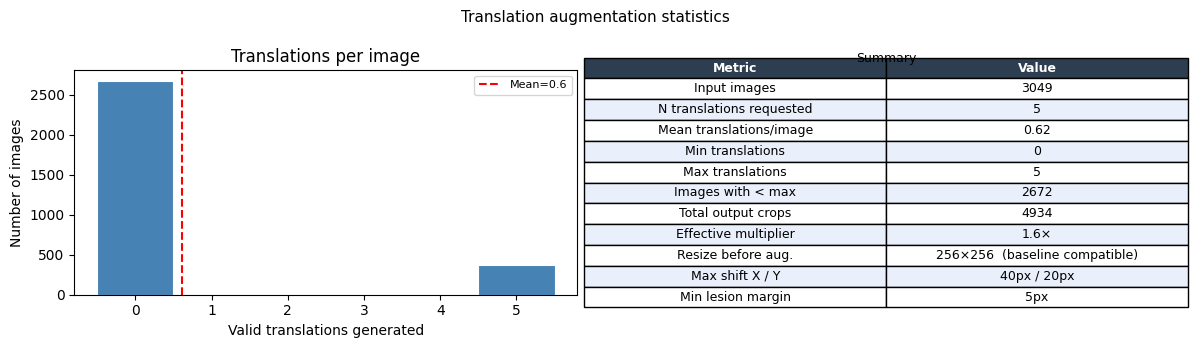

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 4 — Distribution: how many valid translations per image?
# ══════════════════════════════════════════════════════════════════════════

translations_arr = np.array(translations_per_image)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
fig.suptitle('Translation augmentation statistics', fontsize=11)

# Histogram of translations per image
axes[0].hist(translations_arr, bins=range(0, N_TRANSLATIONS + 2),
             color='steelblue', edgecolor='white', linewidth=0.8,
             align='left')
axes[0].axvline(translations_arr.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={translations_arr.mean():.1f}')
axes[0].set_xlabel('Valid translations generated')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Translations per image')
axes[0].legend(fontsize=8)

# Summary table
axes[1].axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Input images',           f"{stats['total_input']}"],
    ['N translations requested',f"{N_TRANSLATIONS}"],
    ['Mean translations/image', f"{translations_arr.mean():.2f}"],
    ['Min translations',        f"{translations_arr.min()}"],
    ['Max translations',        f"{translations_arr.max()}"],
    ['Images with < max',       f"{stats['partial']}"],
    ['Total output crops',      f"{total_saved}"],
    ['Effective multiplier',    f"{total_saved/max(stats['total_input'],1):.1f}×"],
    ['Resize before aug.',       f'{TARGET_SIZE}×{TARGET_SIZE}  (baseline compatible)'],
    ['Max shift X / Y',         f"{MAX_SHIFT_X}px / {MAX_SHIFT_Y}px"],
    ['Min lesion margin',       f"{MIN_LESION_MARGIN}px"],
]
tbl = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF0FB')
axes[1].set_title('Summary', fontsize=9)

plt.tight_layout()
plt.savefig(Path(OUT_OCT_DIR).parent / 'augmentation_stats.png',
            dpi=150, bbox_inches='tight')
plt.show()

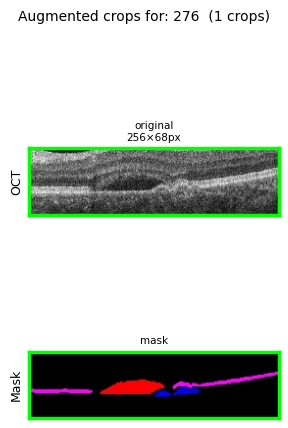

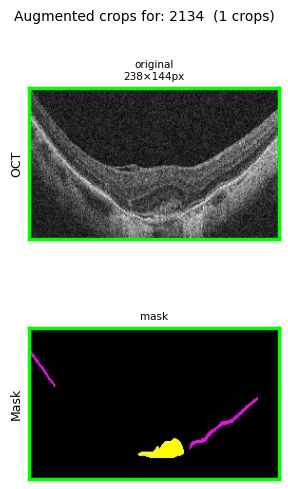

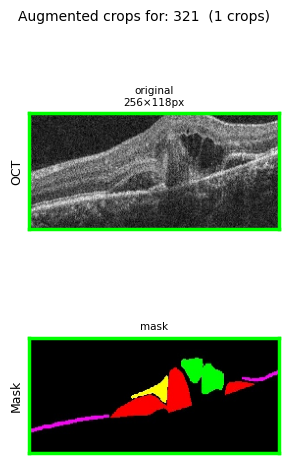

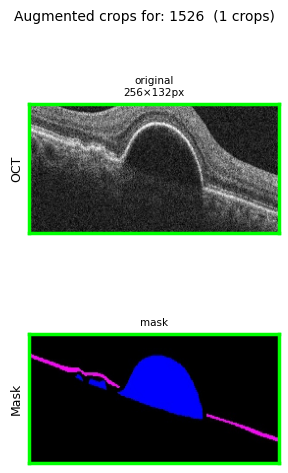

QC complete.

Resize-first augmented dataset ready in:
  All crops drawn from 256×256 canvas — baseline model compatible.
  OCT  : /content/drive/MyDrive/FYP/data/augmented_new/crop_oct
  Mask : /content/drive/MyDrive/FYP/data/augmented_new/crop_mask

Next step: use these folders as CROP_OCT_DIR / CROP_MASK_DIR
in finetune_unet_roi_fixed.ipynb for training.

  Colab tip: output is saved to Google Drive.
  It persists after this session ends.
  In your fine-tune notebook set:
    CROP_OCT_DIR  = "/content/drive/MyDrive/FYP/data/augmented_new/crop_oct"
    CROP_MASK_DIR = "/content/drive/MyDrive/FYP/data/augmented_new/crop_mask"


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5 — QC: Random sample of saved augmented pairs
# Shows 4 random input images, each with their translated crops
# ══════════════════════════════════════════════════════════════════════════

out_oct_dir  = Path(OUT_OCT_DIR)
out_mask_dir = Path(OUT_MASK_DIR)

# Group output files by original stem
from collections import defaultdict
stem_groups = defaultdict(list)
for f in sorted(out_oct_dir.glob('*.png')):
    # Stem format: originalname_t01_r+12_c-8  →  original stem is before _t
    orig_stem = f.stem.split('_t')[0]
    stem_groups[orig_stem].append(f)

sample_stems = random.sample(list(stem_groups.keys()),
                              min(4, len(stem_groups)))

for orig_stem in sample_stems:
    files  = sorted(stem_groups[orig_stem])   # t00, t01, t02 ...
    n_show = len(files)

    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.8, 5.5))
    if axes.ndim == 1:
        axes = axes.reshape(2, -1)
    fig.suptitle(f'Augmented crops for: {orig_stem}  ({n_show} crops)',
                 fontsize=10)

    for col, fpath in enumerate(files):
        oct_c  = cv2.cvtColor(cv2.imread(str(fpath)), cv2.COLOR_BGR2RGB)
        mask_c = cv2.cvtColor(
            cv2.imread(str(out_mask_dir / fpath.name), cv2.IMREAD_COLOR),
            cv2.COLOR_BGR2RGB
        )
        h, w = oct_c.shape[:2]

        # Decode shift from filename
        parts = fpath.stem.split('_t')
        shift_label = 'original' if 't00' in fpath.stem else parts[-1]
        border_col = 'lime' if 't00' in fpath.stem else 'orange'

        axes[0, col].imshow(oct_c,  cmap='gray')
        axes[1, col].imshow(mask_c)
        axes[0, col].set_title(f'{shift_label}\n{w}×{h}px', fontsize=7.5)
        axes[1, col].set_title('mask', fontsize=7.5)

        for row in range(2):
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor(border_col)
                spine.set_linewidth(2.5)
                spine.set_visible(True)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    axes[0, 0].set_ylabel('OCT',  fontsize=9)
    axes[1, 0].set_ylabel('Mask', fontsize=9)
    plt.tight_layout(pad=0.4)
    plt.show()

print('QC complete.')
print(f'\nResize-first augmented dataset ready in:')
print(f'  All crops drawn from {TARGET_SIZE}×{TARGET_SIZE} canvas — baseline model compatible.')
print(f'  OCT  : {OUT_OCT_DIR}')
print(f'  Mask : {OUT_MASK_DIR}')
print()
print('Next step: use these folders as CROP_OCT_DIR / CROP_MASK_DIR')
print('in finetune_unet_roi_fixed.ipynb for training.')

# ── Colab session tip ─────────────────────────────────────────────────────
print('\n' + '='*60)
print('  Colab tip: output is saved to Google Drive.')
print('  It persists after this session ends.')
print('  In your fine-tune notebook set:')
print(f'    CROP_OCT_DIR  = "{OUT_OCT_DIR}"')
print(f'    CROP_MASK_DIR = "{OUT_MASK_DIR}"')
print('='*60)
